## Решение задачи регрессии с помощью нейронных сетей

Определение стоимости недвижимости из набора данных [California Housing Data Set](https://developers.google.com/machine-learning/crash-course/california-housing-data-description).


In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Загружаем данные

In [4]:
train_df = pd.read_csv('california_housing_train.csv')
test_df = pd.read_csv('california_housing_test.csv')

**Описание данных**

California Housing содержит данные о средней стоимость домов в Калифорнии для квартала. Файл с данными содержит следующие столбцы:

*   **longitude** - долгота квартала с недвижимостью.
*   **latitude** - широта квартала с недвижимостью.
*   **housing_median_age** - медиана возраста домов в квартале.
*   **total_rooms** - общее колиичество комнат в квартале.
*   **total_bedrooms** - общее количество спален в квартале.
*   **population** - население квартала.
*   **households** - количество "домохозяйств" в квартале (групп людей живущих вместе в одном доме. Как правило это семьи).
*   **median_income** - медианный доход в квартале.
*   **median_house_value** - медианная стоимость дома в квартале.



In [5]:
"""Смотрим на случайные 3 записи в нашем тренировочном наборе"""
train_df.sample(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2740,-117.69,33.51,4.0,1223.0,275.0,505.0,244.0,4.6607,173000.0
3744,-117.93,33.82,28.0,2444.0,555.0,1848.0,567.0,3.0179,198800.0
3135,-117.83,33.88,18.0,2112.0,340.0,1048.0,315.0,6.9308,231700.0


In [6]:
"""Смотрим на случайные 3 записи в нашем тестовом наборе"""
test_df.sample(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
878,-121.92,37.30,36.0,2088.0,358.0,772.0,347.0,4.2762,310100.0
1102,-118.29,34.08,25.0,2459.0,823.0,2635.0,763.0,2.4000,173900.0
2155,-118.37,33.88,20.0,2439.0,474.0,1219.0,497.0,5.9619,335900.0


## Постановка задачи регрессии

Необходимо определить медианную стоимость дома в квартале, зная все остальные признаки.

**Целевая переменная**: `median_house_value`

**Признаки**: `longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households,	median_income`

Признаки подаются на вход нейронной сети, на выходе сеть должна выдать значение целевой переменной - `median_house_value`

In [7]:
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
target = 'median_house_value'
# Выделяем данные для обучения и преобразуем их в массивы numpy
x_train = train_df[features].values
x_test = test_df[features].values
# Выделяем правильные ответы и преобразуем их в массивы numpy
y_train = train_df[target].values
y_test = test_df[target].values

In [8]:
"""Убедимся, что количество столбцов в данных совпадает"""
x_train.shape, x_test.shape

((17000, 8), (3000, 8))

In [9]:
y_train.shape, y_test.shape

((17000,), (3000,))

**Стандартизация данных**

Вычитаем среднее значение и делим на стандартное отклонение

In [10]:
# Среднее значение
mean = x_train.mean(axis=0)
# Стандартное отклонение
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std

## Создаем нейронную сеть

Выходной слой с одним линейным нейроном - для задачи регрессии функция активации - RELU.

In [11]:
from tensorflow.keras.initializers import TruncatedNormal, Constant

model = Sequential()
model.add(Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

None


**Компилируем сеть**

Функция ошибки - среднеквадратичное отклонение. Метрика - среднее абсолютное отклонение.

In [13]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## Обучаем нейронную сеть

In [14]:
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/500
425/425 - 1s - 3ms/step - loss: 51065843712.0000 - mae: 197038.0000 - val_loss: 76681461760.0000 - val_mae: 245836.1719
Epoch 2/500
425/425 - 0s - 1ms/step - loss: 47983366144.0000 - mae: 189943.6094 - val_loss: 74487447552.0000 - val_mae: 242062.3750
Epoch 3/500
425/425 - 0s - 1ms/step - loss: 39178252288.0000 - mae: 167734.0625 - val_loss: 70044286976.0000 - val_mae: 234103.1406
Epoch 4/500
425/425 - 1s - 2ms/step - loss: 27462094848.0000 - mae: 133727.9844 - val_loss: 64575074304.0000 - val_mae: 223878.7344
Epoch 5/500
425/425 - 1s - 1ms/step - loss: 18487193600.0000 - mae: 104129.9375 - val_loss: 59206283264.0000 - val_mae: 213420.2188
Epoch 6/500
425/425 - 1s - 1ms/step - loss: 14525109248.0000 - mae: 90669.0156 - val_loss: 54226210816.0000 - val_mae: 203159.7500
Epoch 7/500
425/425 - 1s - 1ms/step - loss: 13167440896.0000 - mae: 86999.0469 - val_loss: 49441755136.0000 - val_mae: 192800.2031
Epoch 8/500
425/425 - 1s - 1ms/step - loss: 12347181056.0000 - mae: 84414.0859

## Визуализация качества обучения

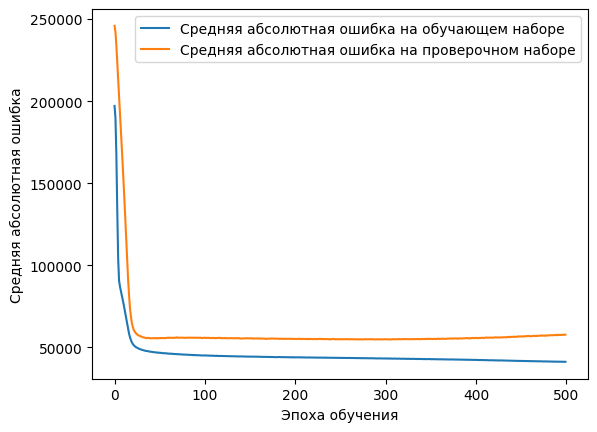

In [15]:
plt.plot(history.history['mae'],
         label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history.history['val_mae'],
         label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка')
plt.legend()
plt.show()

## Проверяем работу модели на тестовом наборе данных

In [16]:
scores = model.evaluate(x_test, y_test, verbose=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4034655488.0000 - mae: 44487.9102


In [17]:
print("Средняя абсолютная ошибка на тестовых данных:", round(scores[1], 4))

Средняя абсолютная ошибка на тестовых данных: 44487.9102
